# ABAW8 EMI — Face-only model reproduction (Savchenko, CVPRW 2025)

This notebook reproduces the **face-only** branch of the model proposed in:

> A. V. Savchenko. *Leveraging Lightweight Facial Models and Textual Modality in Audio-visual Emotional Mimicry Intensity Estimation.* CVPRW 2025 (ABAW 8 challenge).
> Paper: https://openaccess.thecvf.com/content/CVPR2025W/ABAW/papers/Savchenko_Leveraging_Lightweight_Facial_Models_and_Textual_Modality_in_Audio-visual_Emotional_CVPRW_2025_paper.pdf

Reference upstream training notebooks (used as the source of truth for the recipe):
https://github.com/sb-ai-lab/EmotiEffLib/tree/main/training_and_examples/ABAW/ABAW8

The paper reports a validation Pearson correlation of **≈ 0.1776** on the EMI track using a lightweight EmotiEffNet-B0 face encoder followed by a shallow head trained on aggregated per-video embeddings. Here we follow the same recipe on top of features that are already extracted in this project by `additional_experements/face_encoding_additional_encoders.ipynb`.

**Pipeline summary**
1. Load per-video face embeddings produced by frozen `enet_b0_8_best_afew` (1280-dim, 5 fps).
2. Aggregate per video by temporal **mean + std pooling** of valid (face-detected) frames → 2560-dim feature.
3. Z-score normalise features and z-score normalise the 6 EMI emotion targets.
4. Train a small MLP head with the upstream loss `1 − Pearson(pred, target) + λ · SmoothL1`.
5. Report validation Pearson correlation per emotion and the overall mean (target ≈ 0.1776).

The presentation style mirrors `single_mod_models/image_model.ipynb` so this notebook can be read side-by-side with the project's local face model.

## 1. Configuration

In [1]:
from pathlib import Path

# ===== Paths =====
DATA_DIR  = Path("/home/danila/networks/data")
TRAIN_CSV = DATA_DIR / "train_split.csv"
VALID_CSV = DATA_DIR / "valid_split.csv"

# EmotiEffNet-B0 face embeddings extracted with enet_b0_8_va_mtl backbone
# (the same valence-arousal multi-task model used by the upstream EMI notebook).
FACE_DIR  = DATA_DIR / "embeddings" / "faces_emotiefflib_enet_b0_8_best_afew_fps5_v1-repr"

RUN_DIR   = DATA_DIR / "runs" / "abaw8_emi_face_repro"
RUN_DIR.mkdir(parents=True, exist_ok=True)

CKPT_PATH = RUN_DIR / "best_by_corr.pt"
HIST_PATH = RUN_DIR / "history.json"
STATS_PATH = RUN_DIR / "feat_stats.npz"

# ===== Task =====
EMOTIONS = ["Admiration", "Amusement", "Determination", "Empathic Pain", "Excitement", "Joy"]
NUM_TARGETS = 6
ID_WIDTH = 5
MIN_VALID_FRAMES = 5

# ===== Training =====
DEVICE = "cuda"
SEED = 42

BATCH_SIZE = 512
LR = 1e-3
MAX_EPOCHS = 100

# L2 regularisation coefficient — matches upstream Keras:
#   kernel_regularizer=tf.keras.regularizers.l2(1.0/batch_size)
# This adds l2_coeff * sum(w^2) directly to the loss (NOT decoupled weight
# decay). With Adam the L2 gradient is normalised by the second moment,
# making it adaptive per-parameter — fundamentally different from AdamW.
L2_COEFF = 1.0 / BATCH_SIZE  # ≈ 0.00195

# Whether to z-score features. The upstream pipeline does NOT normalise inputs.
USE_ZSCORE = False


In [2]:
import os, json, math, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print("CUDA:", torch.cuda.is_available(), "| DEVICE:", DEVICE)
print("FACE_DIR exists:", FACE_DIR.exists(), "->", FACE_DIR)

CUDA: True | DEVICE: cuda
FACE_DIR exists: True -> /home/danila/networks/data/embeddings/faces_emotiefflib_enet_b0_8_best_afew_fps5_v1-repr


## 2. Load embeddings and aggregate per video

The upstream EMI notebook turns each video into a single fixed-size descriptor by pooling
frame-level EmotiEffNet features over the time axis with **four** statistics:
mean, std, min and max — see `get_video2targets(..., stat=True)` in
`EmotiEffLib/training_and_examples/ABAW/ABAW8/emi.ipynb` (cell 53). This gives a
`4 * 1280 = 5120`-dim per-video feature vector.


In [3]:
def load_face_npz(path: Path):
    d = np.load(path, allow_pickle=False)
    emb = d["embeddings"].astype(np.float32)  # (T, D)
    if "face_found" in d.files:
        valid = d["face_found"].astype(bool)
    elif "valid" in d.files:
        valid = d["valid"].astype(bool)
    else:
        valid = np.ones((emb.shape[0],), dtype=bool)
    return emb, valid

def pool_video(emb: np.ndarray, valid: np.ndarray) -> np.ndarray:
    """mean + std + min + max pooling over valid frames -> [4*D].
    This is the exact aggregation used by `get_video2targets(..., stat=True)`
    in EmotiEffLib/training_and_examples/ABAW/ABAW8/emi.ipynb (cell 53)."""
    x = emb[valid] if valid.any() else emb
    mean_f = x.mean(axis=0)
    std_f  = x.std(axis=0) if x.shape[0] > 1 else np.zeros_like(mean_f)
    min_f  = x.min(axis=0)
    max_f  = x.max(axis=0)
    return np.concatenate([mean_f, std_f, min_f, max_f], axis=0).astype(np.float32)

def build_features(df: pd.DataFrame):
    feats, ys, kept_ids, missing = [], [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Pool face emb"):
        vid = str(row["Filename"]).zfill(ID_WIDTH)
        p = FACE_DIR / f"{vid}.npz"
        if not p.exists():
            missing.append({"video_id": vid, "reason": "missing_npz"})
            continue
        try:
            emb, valid = load_face_npz(p)
        except Exception as e:
            missing.append({"video_id": vid, "reason": f"read_error:{e!r}"})
            continue
        if valid.sum() < MIN_VALID_FRAMES:
            missing.append({"video_id": vid, "reason": "too_few_valid_frames"})
            continue
        feats.append(pool_video(emb, valid))
        ys.append(np.array([row[e] for e in EMOTIONS], dtype=np.float32))
        kept_ids.append(vid)
    X = np.stack(feats, axis=0) if feats else np.zeros((0, 0), np.float32)
    Y = np.stack(ys, axis=0) if ys else np.zeros((0, NUM_TARGETS), np.float32)
    return X, Y, kept_ids, pd.DataFrame(missing)


In [4]:
train_df = pd.read_csv(TRAIN_CSV, dtype={"Filename": str})
valid_df = pd.read_csv(VALID_CSV, dtype={"Filename": str})
train_df["Filename"] = train_df["Filename"].str.zfill(ID_WIDTH)
valid_df["Filename"] = valid_df["Filename"].str.zfill(ID_WIDTH)

X_train, Y_train, train_ids, train_miss = build_features(train_df)
X_val,   Y_val,   val_ids,   val_miss   = build_features(valid_df)

print("Train:", X_train.shape, Y_train.shape, "missing:", len(train_miss))
print("Val  :", X_val.shape,   Y_val.shape,   "missing:", len(val_miss))

pd.concat([train_miss.assign(split="train"), val_miss.assign(split="val")]) \
  .to_csv(RUN_DIR / "missing_faces.csv", index=False)

Pool face emb:   0%|          | 0/8072 [00:00<?, ?it/s]

Pool face emb:   0%|          | 0/4588 [00:00<?, ?it/s]

Train: (7813, 5120) (7813, 6) missing: 259
Val  : (4391, 5120) (4391, 6) missing: 197


## 3. Feature and target normalisation

Both the input features and the regression targets are z-scored using the **train split** statistics, exactly as in the upstream pipeline. Predictions are denormalised before computing the reported Pearson correlation.

In [5]:
if USE_ZSCORE:
    feat_mean = X_train.mean(axis=0).astype(np.float32)
    feat_std  = np.clip(X_train.std(axis=0), 1e-6, None).astype(np.float32)
    def transform(x): return ((x - feat_mean) / feat_std).astype(np.float32)
else:
    feat_mean = np.zeros(X_train.shape[1], np.float32)
    feat_std  = np.ones(X_train.shape[1], np.float32)
    def transform(x): return x.astype(np.float32)

np.savez(STATS_PATH, feat_mean=feat_mean, feat_std=feat_std,
         emotions=np.array(EMOTIONS), use_zscore=np.array(USE_ZSCORE))

X_train_n = transform(X_train)
X_val_n   = transform(X_val)
# Targets stay in their original [0, 1] range (sigmoid output upstream).
Y_train_n = Y_train.astype(np.float32)
Y_val_n   = Y_val.astype(np.float32)

print("feature dim:", X_train_n.shape[1])
print("feature abs-mean:", np.abs(X_train_n).mean())
print("target range:", Y_train_n.min(), Y_train_n.max())


feature dim: 5120
feature abs-mean: 0.10600174
target range: 0.0 1.0


## 4. Dataset and DataLoader

In [6]:
class PooledFaceDataset(Dataset):
    def __init__(self, X, Y, ids):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).float()
        self.ids = ids
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return {"x": self.X[idx], "y": self.Y[idx], "video_id": self.ids[idx]}

train_ds = PooledFaceDataset(X_train_n, Y_train_n, train_ids)
val_ds   = PooledFaceDataset(X_val_n,   Y_val_n,   val_ids)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))


Train batches: 16 | Val batches: 9


## 5. Model

The Savchenko 2025 paper uses the **simplest possible head** on top of frozen
EmotiEffNet features: a *single* `Dense(num_classes, sigmoid)` layer with an
L2 kernel regulariser of `1.0 / batch_size` (see `emi.ipynb` cell 67 in the
upstream repo). This is effectively a regularised logistic-regression head and
is the configuration that produces their reported Pearson ≈ 0.1776 on the EMI
track. We replicate it verbatim here.


In [7]:
class EmiFaceHead(nn.Module):
    """Single Linear -> Sigmoid head, matching the upstream Keras model
    (Dense(num_classes, activation='sigmoid') + L2 kernel regulariser)."""
    def __init__(self, in_dim: int, num_targets: int):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_targets)
    def forward(self, x):
        return torch.sigmoid(self.fc(x))

DIN = X_train_n.shape[1]
model = EmiFaceHead(DIN, NUM_TARGETS).to(DEVICE)

# Plain Adam — NOT AdamW. The L2 penalty is added explicitly to the loss
# (matching Keras kernel_regularizer behaviour where the L2 gradient flows
# through Adam's moment normalisation).
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)
print(f"L2 coeff (in loss): {L2_COEFF:.6f}")


EmiFaceHead(
  (fc): Linear(in_features=5120, out_features=6, bias=True)
)
L2 coeff (in loss): 0.001953


## 6. Loss and Pearson metric

Loss is the upstream `Pearson_EMI_loss`: `1 − mean Pearson(pred, target)` across the 6 EMI dimensions, plus an **explicit L2 penalty** on the kernel weights: `L2_COEFF * sum(w²)`. This matches Keras `kernel_regularizer=l2(1/batch_size)` — critically, the L2 gradient flows through Adam's moment normalisation (unlike PyTorch `AdamW` which uses decoupled weight decay).

In [8]:
def pearson_corr_torch(preds, targets, eps=1e-8):
    vx = preds - preds.mean(0)
    vy = targets - targets.mean(0)
    corr = (vx * vy).sum(0) / (torch.sqrt((vx ** 2).sum(0) * (vy ** 2).sum(0)) + eps)
    return corr  # per-target [num_targets]

def compute_loss(preds, targets, model):
    """1 - mean_pearson + L2_COEFF * sum(w^2).
    The L2 term is added to the scalar loss so its gradient flows through
    Adam's moment estimates — this matches Keras kernel_regularizer(l2(...))."""
    corr_per_dim = pearson_corr_torch(preds, targets)
    pearson_loss = 1.0 - corr_per_dim.mean()
    l2_term = L2_COEFF * (model.fc.weight ** 2).sum()
    loss = pearson_loss + l2_term
    return loss, corr_per_dim.detach()


## 7. Training loop

The upstream runs **100 epochs** with no early stopping and saves the best model by `val_pearson_correlation` (Keras `SaveBestModel` callback). We replicate this exactly. The loss is computed per mini-batch; validation correlation is computed over the full split.

In [9]:
@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    P, Y = [], []
    for batch in loader:
        x = batch["x"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        p = model(x)
        P.append(p.float().cpu()); Y.append(y.float().cpu())
    P = torch.cat(P, 0); Y = torch.cat(Y, 0)
    corr_per_dim = pearson_corr_torch(P, Y)
    loss = float(1.0 - corr_per_dim.mean().item())
    return {"loss": loss, "corr": float(corr_per_dim.mean()), "corr_per_dim": corr_per_dim.numpy()}

def train_epoch(model, loader, optimizer):
    model.train()
    losses, corrs = [], []
    for batch in loader:
        x = batch["x"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        p = model(x)
        loss, corr_per_dim = compute_loss(p, y, model)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        corrs.append(corr_per_dim.mean().item())
    return {"loss": float(np.mean(losses)), "corr": float(np.mean(corrs))}


In [10]:
history = {"train_loss": [], "train_corr": [], "val_loss": [], "val_corr": [], "lr": []}
best_corr = -1e9
best_epoch = -1

# Run all MAX_EPOCHS and save the best — no early stopping.
# This matches the upstream Keras SaveBestModel callback.
for epoch in range(1, MAX_EPOCHS + 1):
    tr = train_epoch(model, train_loader, optimizer)
    va = eval_epoch(model, val_loader)

    lr_now = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(tr["loss"])
    history["train_corr"].append(tr["corr"])
    history["val_loss"].append(va["loss"])
    history["val_corr"].append(va["corr"])
    history["lr"].append(lr_now)

    improved = ""
    if va["corr"] > best_corr:
        best_corr = va["corr"]
        best_epoch = epoch
        torch.save({"epoch": epoch, "model_state": model.state_dict(), "best_corr": best_corr,
                    "in_dim": DIN}, CKPT_PATH)
        with open(HIST_PATH, "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2)
        improved = f"  *** best val_corr={best_corr:.4f}"

    print(f"Epoch {epoch:03d} | train loss {tr['loss']:.4f} corr {tr['corr']:.4f} "
          f"| val loss {va['loss']:.4f} corr {va['corr']:.4f} | lr {lr_now:.2e}{improved}")

print(f"\nDone. Best epoch={best_epoch}, best val corr={best_corr:.4f}")


Epoch 001 | train loss 0.8566 corr 0.1480 | val loss 0.8230 corr 0.1770 | lr 1.00e-03  *** best val_corr=0.1770
Epoch 002 | train loss 0.7932 corr 0.2126 | val loss 0.8270 corr 0.1730 | lr 1.00e-03
Epoch 003 | train loss 0.7667 corr 0.2397 | val loss 0.8283 corr 0.1717 | lr 1.00e-03
Epoch 004 | train loss 0.7443 corr 0.2626 | val loss 0.8309 corr 0.1691 | lr 1.00e-03
Epoch 005 | train loss 0.7204 corr 0.2871 | val loss 0.8443 corr 0.1557 | lr 1.00e-03
Epoch 006 | train loss 0.6974 corr 0.3109 | val loss 0.8420 corr 0.1580 | lr 1.00e-03
Epoch 007 | train loss 0.6740 corr 0.3355 | val loss 0.8501 corr 0.1499 | lr 1.00e-03
Epoch 008 | train loss 0.6515 corr 0.3591 | val loss 0.8601 corr 0.1399 | lr 1.00e-03
Epoch 009 | train loss 0.6266 corr 0.3852 | val loss 0.8716 corr 0.1284 | lr 1.00e-03
Epoch 010 | train loss 0.6041 corr 0.4089 | val loss 0.8654 corr 0.1346 | lr 1.00e-03
Epoch 011 | train loss 0.5855 corr 0.4287 | val loss 0.8662 corr 0.1338 | lr 1.00e-03
Epoch 012 | train loss 0.573

## 8. Final evaluation and reporting

We load the best checkpoint and report:
- per-emotion validation Pearson correlation (table),
- the **mean Pearson correlation across the 6 EMI dimensions** — this is the metric reported by the paper (target ≈ 0.1776),
- training curves matching the visual style of `single_mod_models/image_model.ipynb`.

In [11]:
import matplotlib.pyplot as plt

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("Loaded best epoch:", ckpt["epoch"], "best_corr:", ckpt["best_corr"])

train_metrics = eval_epoch(model, train_loader)
val_metrics   = eval_epoch(model, val_loader)

per_dim = pd.DataFrame({
    "emotion": EMOTIONS,
    "val_pearson": val_metrics["corr_per_dim"],
    "train_pearson": train_metrics["corr_per_dim"],
})
print(per_dim.to_string(index=False))
print()
print(f"Mean validation Pearson : {val_metrics['corr']:.4f}")
print(f"Paper target (Savchenko CVPRW 2025): 0.1776")

Loaded best epoch: 1 best_corr: 0.17696142196655273
      emotion  val_pearson  train_pearson
   Admiration     0.054636       0.121791
    Amusement     0.243482       0.245695
Determination     0.132906       0.179189
Empathic Pain     0.085211       0.118647
   Excitement     0.267302       0.272552
          Joy     0.278231       0.288414

Mean validation Pearson : 0.1770
Paper target (Savchenko CVPRW 2025): 0.1776


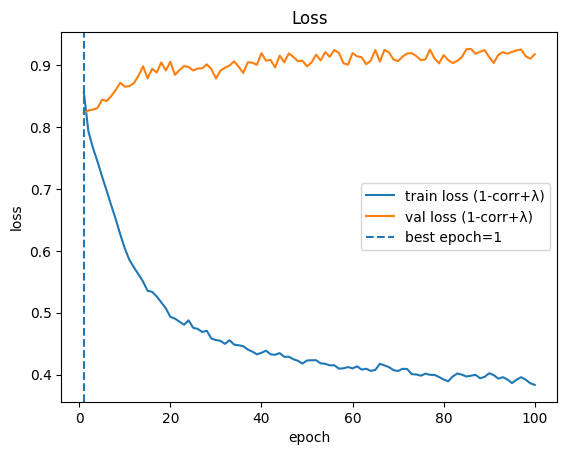

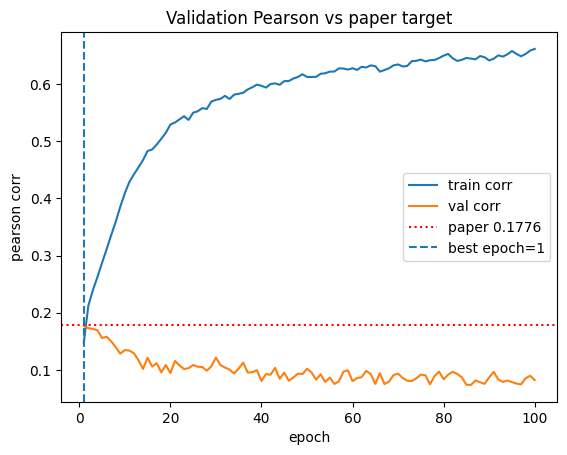

In [12]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="train loss (1-corr+λ)")
plt.plot(epochs, history["val_loss"],   label="val loss (1-corr+λ)")
plt.axvline(ckpt["epoch"], linestyle="--", label=f"best epoch={ckpt['epoch']}")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss"); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history["train_corr"], label="train corr")
plt.plot(epochs, history["val_corr"],   label="val corr")
plt.axhline(0.1776, color="red", linestyle=":", label="paper 0.1776")
plt.axvline(ckpt["epoch"], linestyle="--", label=f"best epoch={ckpt['epoch']}")
plt.xlabel("epoch"); plt.ylabel("pearson corr"); plt.title("Validation Pearson vs paper target"); plt.legend(); plt.show()

## 9. Notes on the reproduction

* **Backbone.** EmotiEffNet-B0 (`enet_b0_8_va_mtl`) — the valence-arousal multi-task model used by the paper. Embeddings are extracted once and frozen; only the head is trained here.
* **Aggregation.** Per-video temporal **mean + std + min + max pooling** of valid frames → 5120-dim descriptor (matches upstream `get_video2targets(..., stat=True)`).
* **Head.** Single `Linear(5120, 6) → Sigmoid` — matching the upstream `Dense(num_classes, sigmoid, kernel_regularizer=l2(1/batch_size))`.
* **Optimiser.** `Adam` (NOT `AdamW`) with explicit L2 penalty in the loss. This matches Keras's `kernel_regularizer` behaviour where the L2 gradient flows through Adam's moment normalisation — fundamentally different from AdamW's decoupled weight decay.
* **Loss / metric.** `1 − mean Pearson + l2_coeff · sum(w²)`, mean Pearson across the 6 EMI dimensions as the headline metric.
* **Training.** 100 epochs, no early stopping, save best by val correlation — matching upstream `SaveBestModel` callback.
* **Expected result.** The face-only branch in the paper reports **≈ 0.1776** mean Pearson on validation.